# Frequency scan of the final pulse in a truncated LMT sequence

This notebook reuses the same lab pulse sequence as `true_LMT_trajectory.ipynb`,
truncates it to the first `N` pulses (start with `N = 2`), and then scans the
laser frequency (detuning) of the **final, Nth pulse**.

For each detuning we run the full Bordé-frame simulation for an *ideal atom* —
one with no extra velocity (it sits at the centre of the velocity distribution,
i.e. exactly the `INITIAL_VELOCITY_Z` the sequence was designed for) and at the
centre of the cloud (`position = 0`). The output is the excitation fraction
versus the final-pulse detuning.

In [1]:
import sys
import dataclasses

sys.path.insert(0, '..')

import numpy as np
import matplotlib.pyplot as plt

import lmt_sim.lmt_simulation as sim
import lmt_sim.lmt_sequence as seq

## Lab pulse dump

Same dump and `INITIAL_VELOCITY_Z` as `true_LMT_trajectory.ipynb`.

In [2]:
pulse_sequence = [[[1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 1, 0, 0, 1, 1, 0, 1, 1, 0, 0, 1, 1, 0], [4936, 2691191, 2771190, 2838189, 2918188, 2985187, 3065186, 3132185, 3212184, 3279183, 3359182, 3426181, 3506180, 3573179, 3653178, 3720177, 3800176, 4077207, 4122991, 4286111, 4392695, 4722709, 4809244, 4922367, 5030207, 5108734, 5221855, 5328439, 5508438, 5594973, 5908111, 6019623], [380000, 68000, 54999, 68000, 54999, 68000, 54999, 68000, 54999, 68000, 54999, 68000, 54999, 68000, 54999, 68000, 54999, 34000, 99999, 99999, 68000, 68000, 99999, 99999, 68000, 99999, 99999, 68000, 68000, 99999, 99999, 34000], [80000000, 79971814, 80020109, 79988550, 80003372, 80005286, 79986636, 80022022, 79969900, 80038758, 79953164, 80055494, 79936428, 80072230, 79919692, 80088966, 79902956, 80027353, 79983322, 79966812, 80004123, 79999490, 79974157, 79994546, 80013772, 79978362, 79998751, 80028585, 80026058, 80003989, 79989586, 80000149], [200000000, 200005800, 200001500, 200005800, 200001500, 200005800, 200001500, 200005800, 200001500, 200005800, 200001500, 200005800, 200001500, 200005800, 200001500, 200005800, 200001500, 200005800, 200000500, 200000500, 200005800, 200005800, 200000500, 200000500, 200005800, 200000500, 200000500, 200005800, 200005800, 200000500, 200000500, 200005800], [99485300, 99485300, 99485300, 99485300, 99485300, 99485300, 99485300, 99485300, 99485300, 99485300, 99485300, 99485300, 99485300, 99485300, 99485300, 99485300, 99485300, 99485300, 99485300, 99485300, 99485300, 99485300, 99485300, 99485300, 99485300, 99485300, 99485300, 99485300, 99485300, 99485300, 99485300, 99485300], [2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2]]]

(
    is_up,
    start_times_mu,
    durations_mu,
    opll_hz,
    switch_hz,
    delivery_hz,
    delivery_setpoint,
) = pulse_sequence[0]

is_up = np.array(is_up)
start_times_mu = np.array(start_times_mu)
durations_mu = np.array(durations_mu)
opll_hz = np.array(opll_hz)
switch_hz = np.array(switch_hz)
delivery_hz = np.array(delivery_hz)
delivery_setpoint = np.array(delivery_setpoint)

# Initial (t=0) atomic velocity along z, in m/s. The sequence detunings are
# built to compensate the Doppler shift of an atom moving at this velocity, so
# the "ideal" atom is the one travelling at exactly INITIAL_VELOCITY_Z.
INITIAL_VELOCITY_Z = -1.6888e-3  # m/s

In [3]:
sequence = seq.build_sequence_from_lab_pulse_dump(
    is_up=is_up,
    start_times_mu=start_times_mu,
    durations_mu=durations_mu,
    opll_hz=opll_hz,
    switch_hz=switch_hz,
    delivery_hz=delivery_hz,
    delivery_setpoint=delivery_setpoint,
    initial_velocity_z=INITIAL_VELOCITY_Z,
)

# Skip the first freefall, exactly as in true_LMT_trajectory.ipynb, so the
# sequence starts on the first pulse.
sequence = sequence[1:]

print(f'{len(sequence)} events, '
      f'{sum(isinstance(e, seq.Pulse) for e in sequence)} pulses')

63 events, 32 pulses


## Truncate to N pulses

Keep every event up to and including the Nth pulse (so any trailing freefall
after the Nth pulse is dropped — it does not change the excitation fraction).

In [4]:
def truncate_to_n_pulses(events, n):
    """Return the prefix of `events` ending on the nth Pulse (1-indexed)."""
    out = []
    n_pulses = 0
    for event in events:
        out.append(event)
        if isinstance(event, seq.Pulse):
            n_pulses += 1
            if n_pulses == n:
                return out
    raise ValueError(
        f'Sequence only contains {n_pulses} pulses, cannot truncate to {n}'
    )


N = 2
truncated = truncate_to_n_pulses(sequence, N)

print(f'Truncated to {N} pulses: '
      f'{[type(e).__name__ for e in truncated]}')

final_pulse = truncated[-1]
base_detuning_hz = final_pulse.detuning_hz
print(f'Final pulse base detuning: {base_detuning_hz:.1f} Hz '
      f'({base_detuning_hz / sim.RECOIL_FREQUENCY_HZ:.3f} recoil freqs)')

Truncated to 2 pulses: ['Pulse', 'Freefall', 'Pulse']
Final pulse base detuning: 15393.1 Hz (3.270 recoil freqs)


## Scan the final-pulse detuning

We sweep the final pulse's `detuning_hz` around its design value and record the
excitation fraction of the ideal atom. Distances are quoted in recoil
frequencies (`sim.RECOIL_FREQUENCY_HZ`).

In [5]:
# Scan range, expressed in recoil frequencies relative to the design detuning.
scan_halfwidth_recoils = 4.0
n_points = 121

detuning_offsets_recoils = np.linspace(
    -scan_halfwidth_recoils, scan_halfwidth_recoils, n_points
)
scan_detunings_hz = (
    base_detuning_hz + detuning_offsets_recoils * sim.RECOIL_FREQUENCY_HZ
)

excitation_fraction = np.empty(n_points)
for i, detuning_hz in enumerate(scan_detunings_hz):
    scanned_sequence = list(truncated)
    scanned_sequence[-1] = dataclasses.replace(
        scanned_sequence[-1], detuning_hz=detuning_hz
    )
    excitation_fraction[i] = seq.calculate_excited_fraction_for_pulse_sequence(
        scanned_sequence,
        velocity=(0.0, 0.0, INITIAL_VELOCITY_Z),
        position=(0.0, 0.0, 0.0),
    )

print(f'Excitation fraction range: '
      f'{excitation_fraction.min():.4f} .. {excitation_fraction.max():.4f}')

Excitation fraction range: 0.0049 .. 0.9994


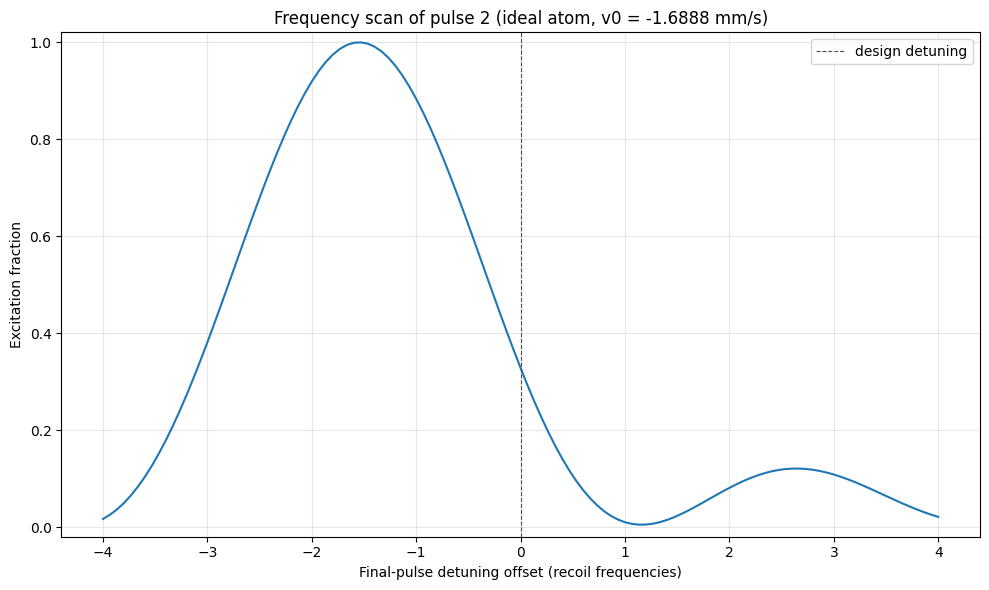

In [6]:
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(detuning_offsets_recoils, excitation_fraction, color='tab:blue')
ax.axvline(0.0, color='0.3', linewidth=0.8, linestyle='--',
           label='design detuning')
ax.set_xlabel('Final-pulse detuning offset (recoil frequencies)')
ax.set_ylabel('Excitation fraction')
ax.set_title(
    f'Frequency scan of pulse {N} (ideal atom, '
    f'v0 = {INITIAL_VELOCITY_Z * 1e3:.4f} mm/s)'
)
ax.set_ylim(-0.02, 1.02)
ax.grid(True, alpha=0.3)
ax.legend(loc='upper right')
plt.tight_layout()
plt.show()